# Estimating Time to Payment for Receivables


In this notebook, I will deep dive on analysis of two specific cases with high concentration of assets in the company. 
Then, after excluiding these cases which have specific policies, design a modeling strategy for a general population

In [1]:
import sys
sys.path.append('../')
from case.helper_functions import plot_km_curve_category,create_duration_table, add_company_info, add_quod_info

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd


From previous analysis, I have designed a pipeline to go from assets table, to duration table, and then joining them with company and quod complimentary data. the modularized code for each step is in the helper_functions module. 

In [2]:
assets = pd.read_parquet('../data/df_assets.parquet')

In [3]:
duration_table = create_duration_table(assets)

In [4]:
company = pd.read_parquet('../data/df_company_data.parquet')
quod = pd.read_parquet('../data/df_quod.parquet')

In [5]:
duration_table = add_company_info(duration_table, company)
duration_table = add_quod_info(duration_table, quod)

In [6]:
duration_table.head()

,asset_id,tax_id,face_value,created_at,settled_at,due_date,reference_date,duration_days,paid,late_payment,...,secondary_cnae_array,legal_nature,is_mei,city,state,zipcode,has_company_info,quod_score,presumed_revenue,has_quod_info
0,5c764ad8-59dc-e30a-9d73-b051582605fb,60259422305974,534.41,2025-03-13,2025-04-06,2025-04-10,2025-04-15,24.0,1,0,...,"[{""classe"":""46.37-1"",""descricao"":""Comércio ata...",Sociedade Empresária Limitada,False,Trindade,Goiás,75384618,1,920.0,1.286888e+08,1
1,b947a6c4-6e17-a418-091d-c04952f85047,00925347588806,165.14,2024-12-03,2024-12-22,2024-12-24,2025-03-19,19.0,1,0,...,NULL,NULL,NULL,NULL,NULL,NULL,0,-1.0,-1.000000e+00,0
2,a314edf1-9bf6-6d6c-bca5-55d1349b19d5,14133781557079,432.55,2024-01-26,2024-02-01,2024-02-02,2025-03-20,6.0,1,0,...,NULL,NULL,NULL,NULL,NULL,NULL,0,-1.0,-1.000000e+00,0
3,c9877d94-5168-849f-42f7-3bf4ef46bf31,14133781557079,102.60,2023-02-28,2023-03-07,2023-03-08,2025-03-20,7.0,1,0,...,NULL,NULL,NULL,NULL,NULL,NULL,0,-1.0,-1.000000e+00,0
4,3ee1a83eb0ba837d,87924474238085,6739.70,2024-06-24,2024-08-06,2024-08-08,2025-02-03,43.0,1,0,...,NULL,NULL,NULL,NULL,NULL,NULL,0,-1.0,-1.000000e+00,0


In [7]:
duration_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980178 entries, 0 to 980177
Data columns (total 28 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   asset_id               980178 non-null  object        
 1   tax_id                 980178 non-null  object        
 2   face_value             980178 non-null  float64       
 3   created_at             980178 non-null  datetime64[ns]
 4   settled_at             868146 non-null  datetime64[ns]
 5   due_date               980178 non-null  datetime64[ns]
 6   reference_date         980178 non-null  datetime64[ns]
 7   duration_days          980178 non-null  float64       
 8   paid                   980178 non-null  int64         
 9   late_payment           980178 non-null  int64         
 10  cohort_month           980178 non-null  object        
 11  cohort_year            980178 non-null  object        
 12  company_status         980178 non-null  obje

# Two specific use cases on Portfolio!

See that there is a huge concentration on assets of two sellers identified as (60259422305974, a wholesale seller of medical supplies, and an udentified company with registry 14133781557079). These companies together share approximately 70% of Credix portfolio

In [8]:
duration_table.tax_id.value_counts(normalize=True)

tax_id
60259422305974    0.428024
14133781557079    0.274790
00925347588806    0.091378
32000772773675    0.063524
87924474238085    0.042983
                    ...   
99881788189631    0.000001
87558830246197    0.000001
28140959347687    0.000001
16149631369090    0.000001
65071673858838    0.000001
Name: proportion, Length: 642, dtype: float64

In [9]:
goias_pharma = duration_table.loc[duration_table.tax_id == '60259422305974']
goias_pharma.head()

,asset_id,tax_id,face_value,created_at,settled_at,due_date,reference_date,duration_days,paid,late_payment,...,secondary_cnae_array,legal_nature,is_mei,city,state,zipcode,has_company_info,quod_score,presumed_revenue,has_quod_info
0,5c764ad8-59dc-e30a-9d73-b051582605fb,60259422305974,534.41,2025-03-13,2025-04-06,2025-04-10,2025-04-15,24.0,1,0,...,"[{""classe"":""46.37-1"",""descricao"":""Comércio ata...",Sociedade Empresária Limitada,False,Trindade,Goiás,75384618,1,920.0,1.286888e+08,1
8,047388a0-5328-e748-da58-ecc8e31fbb5a,60259422305974,527.90,2025-03-27,NaT,2025-05-08,2025-04-15,19.0,0,0,...,"[{""classe"":""46.37-1"",""descricao"":""Comércio ata...",Sociedade Empresária Limitada,False,Trindade,Goiás,75384618,1,920.0,1.286888e+08,1
10,c02772df-b323-fbe6-110f-88fc09001c8b,60259422305974,234.25,2025-02-04,2025-03-30,2025-04-01,2025-04-15,54.0,1,0,...,"[{""classe"":""46.37-1"",""descricao"":""Comércio ata...",Sociedade Empresária Limitada,False,Trindade,Goiás,75384618,1,920.0,1.286888e+08,1
12,f77d1362-1711-a866-e478-59e4f6c0a16e,60259422305974,1662.07,2024-09-10,2024-10-12,2024-10-15,2025-04-15,32.0,1,0,...,"[{""classe"":""46.37-1"",""descricao"":""Comércio ata...",Sociedade Empresária Limitada,False,Trindade,Goiás,75384618,1,920.0,1.286888e+08,1
13,fedd4953-c98b-3aeb-8664-0d6085c3810a,60259422305974,164.55,2024-04-24,2024-06-24,2024-06-26,2025-04-15,61.0,1,0,...,"[{""classe"":""46.37-1"",""descricao"":""Comércio ata...",Sociedade Empresária Limitada,False,Trindade,Goiás,75384618,1,920.0,1.286888e+08,1


putting a flag on Goias pharma company, and plotting a comparative KM curve for general public, we see that this company does not have a good payment profile, lingering on early payments and having a poorer performance in the long run compared to the general public

In [10]:
duration_table['goias_pharma'] = np.where(duration_table.tax_id == '60259422305974', 1, 0)


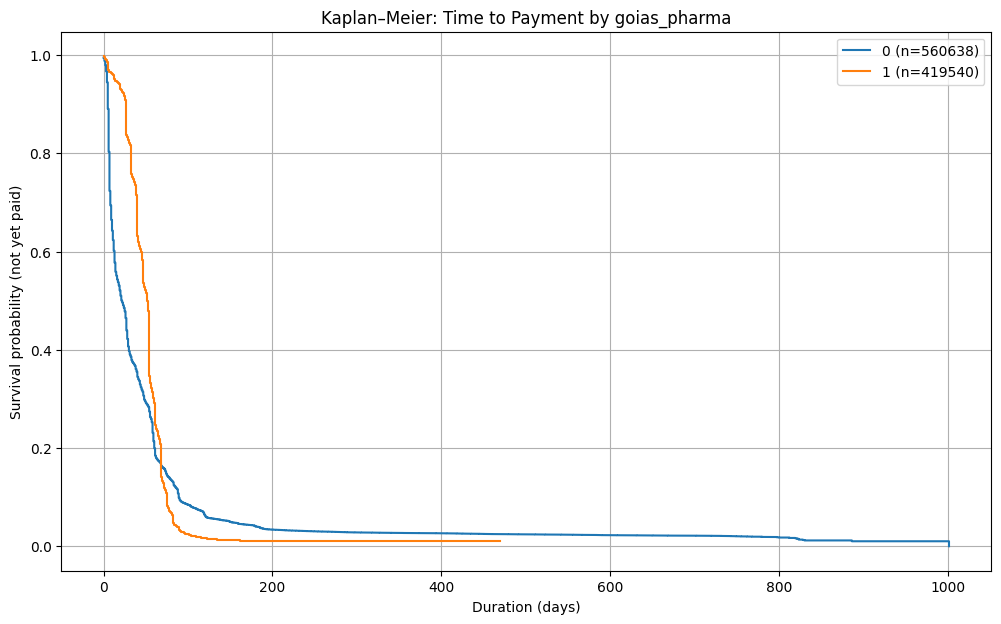

[0, 1]

In [11]:
plot_km_curve_category('goias_pharma', duration_table)

In [12]:
aux = goias_pharma.groupby(['paid', 'cohort_year'])['tax_id'].count().unstack()
aux

cohort_year,2024,2025
paid,,
0,3530,48564
1,316920,50526


<Axes: xlabel='paid'>

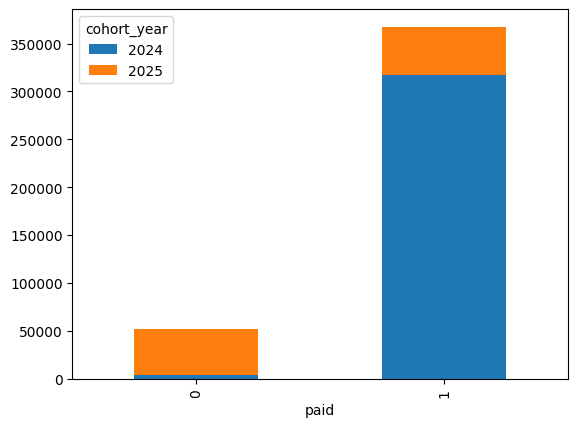

In [13]:
aux.plot(kind='bar', stacked=True)

As a recommendation, I would recommend taking a careful look at this seller, as Credix is highly exposed to this vendor. THe default in 2025, arose mainly because of this vendor. Its median day for paymen is 47 days. On 2025, Credix had 27MM reais without payment, so far

In [14]:
goias_pharma.duration_days.median()

np.float64(47.0)

In [15]:
goias_pharma.loc[goias_pharma.paid==0].groupby('cohort_year')['face_value'].sum()

cohort_year
2024     2940073.42
2025    27888754.05
Name: face_value, dtype: float64

---

# Another specific case, client 14133781557079

This seller comprises about 30% of Credix assets  portfolio and seems to have a good payment behavior overall, with quick payments. There is no data related to this customer in either  company or bureau data.

In [21]:
good_seller = duration_table.loc[duration_table.tax_id == '14133781557079'].head()
good_seller.head()

,asset_id,tax_id,face_value,created_at,settled_at,due_date,reference_date,duration_days,paid,late_payment,...,is_mei,city,state,zipcode,has_company_info,quod_score,presumed_revenue,has_quod_info,goias_pharma,14133781557079
2,a314edf1-9bf6-6d6c-bca5-55d1349b19d5,14133781557079,432.55,2024-01-26,2024-02-01,2024-02-02,2025-03-20,6.0,1,0,...,NULL,NULL,NULL,NULL,0,-1.0,-1.0,0,0,1
3,c9877d94-5168-849f-42f7-3bf4ef46bf31,14133781557079,102.60,2023-02-28,2023-03-07,2023-03-08,2025-03-20,7.0,1,0,...,NULL,NULL,NULL,NULL,0,-1.0,-1.0,0,0,1
7,bc45ac40-9219-9255-1f25-fd143cfd7a19,14133781557079,124.48,2023-08-31,2023-10-04,2023-09-08,2025-03-20,34.0,1,1,...,NULL,NULL,NULL,NULL,0,-1.0,-1.0,0,0,1
9,544e1cc7-b1c9-0426-0e01-a518f469fba7,14133781557079,115.15,2023-03-08,2023-03-19,2023-03-19,2025-03-20,11.0,1,0,...,NULL,NULL,NULL,NULL,0,-1.0,-1.0,0,0,1
11,81e690cd-90ca-0d01-ca2d-e33bc2867778,14133781557079,877.05,2024-02-20,2024-02-27,2024-02-28,2025-03-20,7.0,1,0,...,NULL,NULL,NULL,NULL,0,-1.0,-1.0,0,0,1


In [30]:
duration_table['14133781557079'] = np.where(duration_table.tax_id == '14133781557079', 1, 0)


This customer is indeed a great customer and should be accompanied closely in order to keep its good relationship with Credix. Invoices are usually paid in 7 days, and there is no defaulted or censored assets for this client in the asset historical data!

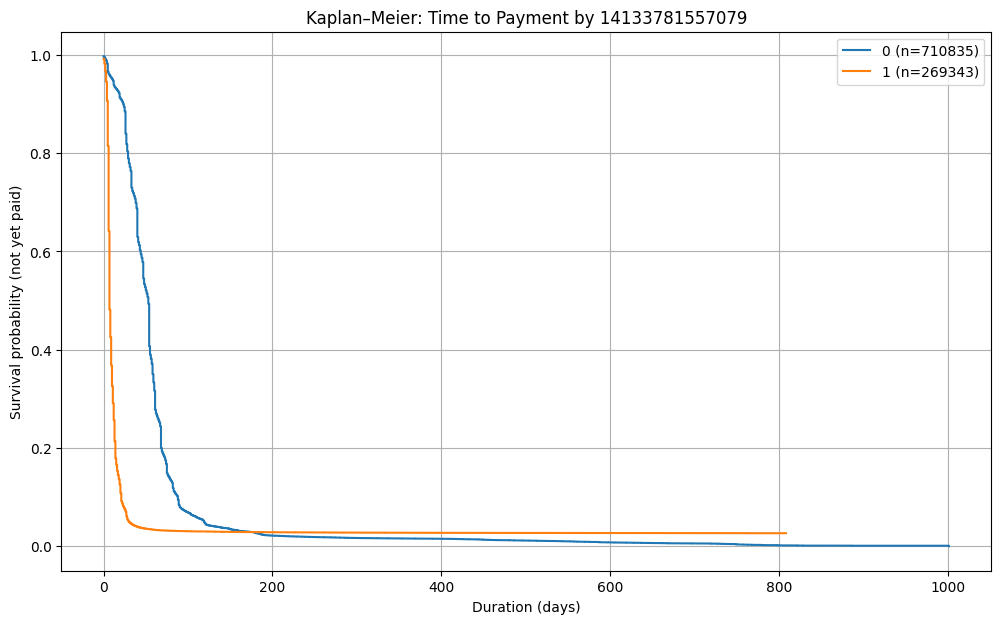

[0, 1]

In [32]:
plot_km_curve_category('14133781557079', duration_table)

In [33]:
good_seller.duration_days.median()

np.float64(7.0)

In [34]:
good_seller.loc[good_seller.paid==0]

,asset_id,tax_id,face_value,created_at,settled_at,due_date,reference_date,duration_days,paid,late_payment,...,is_mei,city,state,zipcode,has_company_info,quod_score,presumed_revenue,has_quod_info,goias_pharma,14133781557079


---

Moving on, we will now make a predictive model for the rest of population in the assets dataset

# Takeaways

## Two specific sellers of Credix Portfolio will not be used for construction of a time to payment model as they are prevalent in Credix Portfolio:


*    **60259422305974** (a whoselase vendor of medical products in Goias) - comprises more than 40% of Credix portfolio and has a high volume of recent defaults (25 MM). **Special attention must be taken on this client and Credix needs to look up if it is meaningful to keep business with this client**

*    **14133781557079** a vendor with no registry in either company or bureau data, but with high exposition in the company. It has a good payment behavior, but it must be accompanied for the comercial team in order to streghten business and apply KYC policies to this specific vendor, in order to understanding its business nature.